# FStrings BEGINNER

Esta tabla contiene la información adicional de las sentencias de tipo JoinedStr (Strings formateados).

## 1 - Obtencion de datos

In [1]:
import matplotlib.pyplot as plt
from notebooks_utils import *

TARGET_FEATURE = 'fstring__expertise_level'
TARGET_CLASS = 'BEGINNER'
full_table = get_data('fstrings')

instances_for_class_low = len(full_table[full_table[TARGET_FEATURE] == "BEGINNER"])
instances_for_class_high = len(full_table[full_table[TARGET_FEATURE] == "PROFESSIONAL"])

print(f"The dataset contains {instances_for_class_low} ({instances_for_class_low/len(full_table)*100:.4}%) instances for BEGINNER class and {instances_for_class_high} ({instances_for_class_high/len(full_table)*100:.4}%) for PROFESSIONAL class.")

2025-04-14 10:58:41.210735 Data cache files found ...
2025-04-14 10:58:41.227695 Data cache files successfully loaded!!
The dataset contains 3118 (33.73%) instances for BEGINNER class and 6127 (66.27%) for PROFESSIONAL class.


In [2]:
full_table = full_table[full_table[TARGET_FEATURE] == TARGET_CLASS]

# Table name, features and target.
TABLE_NAME = 'fstrings'
TABLE_FEATURES = ['fstring__number_of_elements', 'fstring__constants_pct', 'fstring__expressions_pct']

# Load features and target.
X = full_table[TABLE_FEATURES]

# Print information about the loaded table.
print(f'Features shape: {X.shape}')

print(f'As we can see the downloaded data contains a total of {X.shape[0]} instances. For each instance we have {X.shape[1]} attributes.')

Features shape: (3118, 3)
As we can see the downloaded data contains a total of 3118 instances. For each instance we have 3 attributes.


## 2 - Exploracion de datos

Una vez tenemos nuestra tabla en un dataframe el siguiente paso es explorarla para ver qué tipo de información contiene.

In [3]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3118 entries, 6127 to 9244
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   fstring__number_of_elements  3118 non-null   int64  
 1   fstring__constants_pct       3118 non-null   float64
 2   fstring__expressions_pct     3118 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 97.4 KB
None


Cómo podemos ver la tabla está compuesta por 3 variables numéricas y 1 de tipo objeto.

### 2.1 - Valores Nulos 
Miramos si alguna de las variables que contiene la tabla contiene algún valor que sea nulo.

In [4]:
X.isnull().sum()

fstring__number_of_elements    0
fstring__constants_pct         0
fstring__expressions_pct       0
dtype: int64

In [5]:
print_empty_cols(X)

fstring__number_of_elements
---------------------------
0 instancias no tienen un valor para la columna fstring__number_of_elements


fstring__constants_pct
----------------------
0 instancias no tienen un valor para la columna fstring__constants_pct


fstring__expressions_pct
------------------------
0 instancias no tienen un valor para la columna fstring__expressions_pct




### 2.2 - Describimos los valores de las variables de la tabla.

In [6]:
np.transpose(X.describe(percentiles=[.25, .50, .75], include = ['object', 'float', 'bool', 'int']))

,count,mean,std,min,25%,50%,75%,max
fstring__number_of_elements,3118.0,3.383258,2.202094,1.0,2.000000,3.0,4.000000,43.0
fstring__constants_pct,3118.0,0.575010,0.167706,0.0,0.500000,0.5,0.666667,1.0
fstring__expressions_pct,3118.0,0.424990,0.167706,0.0,0.333333,0.5,0.500000,1.0


Vamos a discretizar las variables numericas, agrupando conjuntos de valores en categorias, para hacer un análisis de los datos. Para cada variable es necesaario ver la distribucion de lo valores para hacer los bins (categorias).

In [7]:
# DISCRETIZATION
X_copy = X.copy()

discretized_columns = {
    "fstring__number_of_elements": [(0.0, 2.0), (2.0, 3.0), (3.0, 4.0), (4.0, inf)],  # min: 0.0 max:44.0
    "fstring__constants_pct": [(0.0, 0.5), (0.5, 0.5), (0.5, 0.67), (0.67, inf)],  # min: 0.0 max: 1.0
    "fstring__expressions_pct": [(0.0, 0.33), (0.33, 0.5), (0.5, 0.5), (0.5, inf)],  # min: 0.0 max: 1.0
}

discretize_columns(X_copy, discretized_columns)
    
# SINGLE FEATURE
print("--- SINGLE FEATURE ---")
print(get_statistics(X_copy, ['fstring__number_of_elements'], 10))
print(get_statistics(X_copy, ['fstring__constants_pct'], 10))
print(get_statistics(X_copy, ['fstring__expressions_pct'], 10))


# 2 FEATURES
print("--- TWO FEATURES ---")
#print(get_statistics(X_copy, ['module__function_defs_pct', 'module__number_of_classes'], 10))

# 3 FEATURES
print("--- THREE FEATURES ---")
#print(get_statistics(X_copy, ['module__class_defs_pct', 'module__function_defs_pct', 'module__enum_defs_pct'], 10))

--- SINGLE FEATURE ---
fstring__number_of_elements  count  percentage
                  [4.0_inf]    957   30.692752
                  [2.0_3.0)    955   30.628608
                  [3.0_4.0)    904   28.992944
                  [0.0_2.0)    302    9.685696

fstring__constants_pct  count  percentage
             [0.5_0.5]   1450   46.504169
            [0.5_0.67)   1254   40.218089
            [0.67_inf]    225    7.216164
             [0.0_0.5)    189    6.061578

fstring__expressions_pct  count  percentage
               [0.5_0.5]   1450   46.504169
              [0.33_0.5)   1254   40.218089
              [0.0_0.33)    225    7.216164
               [0.5_inf]    189    6.061578

--- TWO FEATURES ---
--- THREE FEATURES ---


In [8]:
def normalize_datatypes(X:pd.DataFrame) -> (pd.DataFrame, [str]):
    X = pd.get_dummies(X)
    X = X.astype('float32')        
    columns_names = X.columns.tolist()
    return X, columns_names

X, TABLE_FEATURES = normalize_datatypes(X)
# Print information about the loaded table
print(f'Features shape: {X.shape}')

Features shape: (3118, 3)


#### Muestra la matriz de correlación de Spearman entre las variables de la tabla.

<Axes: >

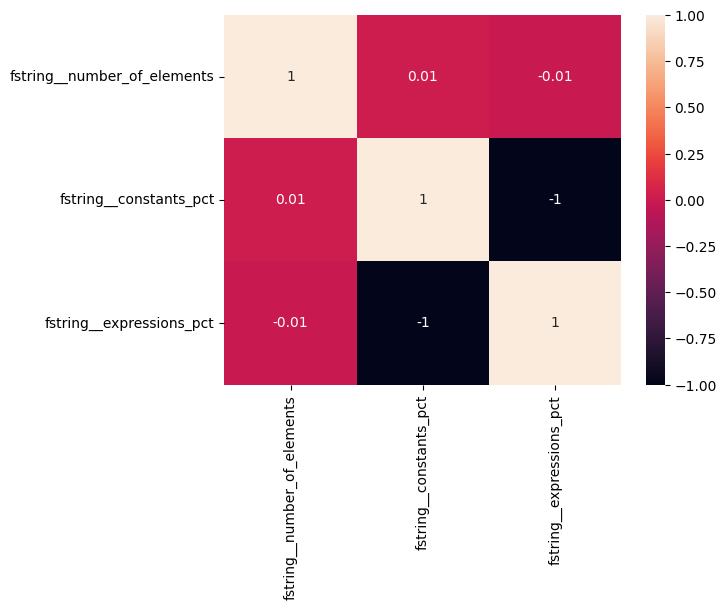

In [9]:
sns.heatmap(X.corr(method='spearman'), annot=True)

## 3 - Detección de valores atípicos (outliers)
## Univariate
## Analisis detallado de variables
Para cada una de las 3 variables (1 numerica y 2 porcentuales) se hara un analisis detallado

### Variable number_of_elements (1/3)
Esta variable representa el número de elementos del JoinedStr. Como vimos en la descripción de la tabla esta varibale adopta valores en el rango 1 - 43. Con una media de 3.38.

<Axes: ylabel='fstring__number_of_elements'>

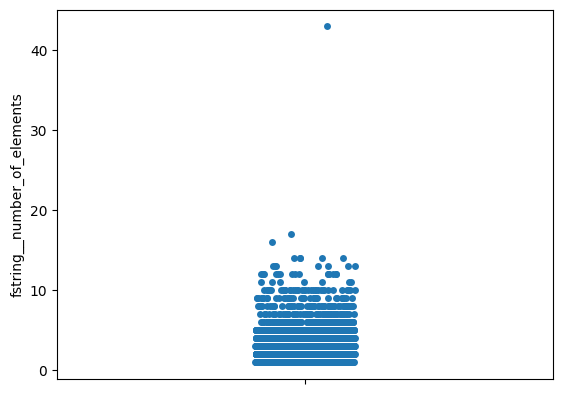

In [10]:
sns.stripplot(X['fstring__number_of_elements'])

### IMPORTANTE
El valor maximo esta muy alejado de los siguientes

In [11]:
print_outliers_for_df_column(X, 'fstring__number_of_elements')

El coeficiente MC (Medcouple Coefficient) de balanceo es: 0.7561890596435183
Dependiendo del coeficiente de MC se deben tomar unos límites u otros:
     |MC| < 0.3    ->  Tukey
     |MC| >=  0.3  ->  MAD
Rango valores atípicos leves (Tukey): [-1.0,7.0]
Rango valores atípicos MAD (Median Absolute Deviation): [-0.08011817932128906,6.463376760482788]
-1.5IQR: 0 instancias tienen un valor para fstring__number_of_elements inferior a -1.0 (Q1-1.5*IQR) para fstring__number_of_elements. Representando un 0.0% del total de instancias.
+1.5IQR: 169 instancias tienen un valor para fstring__number_of_elements superior a 7.0 (Q3+1.5*IQR) para fstring__number_of_elements. Representando un 5.42% del total de instancias.
MAD Inferior: 0 instancias tienen un valor para fstring__number_of_elements inferior a -0.08011817932128906 para fstring__number_of_elements. Representando un 0.0% del total de instancias.
MAD Superior: 230 instancias tienen un valor para fstring__number_of_elements superior a 6.463376

,fstring__number_of_elements,fstring__constants_pct,fstring__expressions_pct
count,230.000000,230.000000,230.000000
mean,9.078260,0.524478,0.475522
std,2.967503,0.038987,0.038987
min,7.000000,0.285714,0.428571
25%,7.000000,0.500000,0.444444
50%,8.000000,0.500000,0.500000
75%,10.000000,0.555556,0.500000
max,43.000000,0.571429,0.714286


In [12]:
analizar_bins(X, 'fstring__number_of_elements')


--- Análisis de la feature: 'fstring__number_of_elements' ---

Discretización en 3 bins de **igual anchura**:
  (0.958, 15.0]: 3115 (99.9%)
  (15.0, 29.0]: 2 (0.1%)
  (29.0, 43.0]: 1 (0.0%)

Discretización en 3 bins de **igual frecuencia**:
  (0.999, 2.0]: 1257 (40.3%)
  (2.0, 3.0]: 904 (29.0%)
  (3.0, 43.0]: 957 (30.7%)


### Variable constants_pct (2/3)
Esta variable representa la proporción de los valores usados para parametrizar el JoinedStr que son constantes. Toma los valores de 0.0 - 1.0. La media es 0.57.

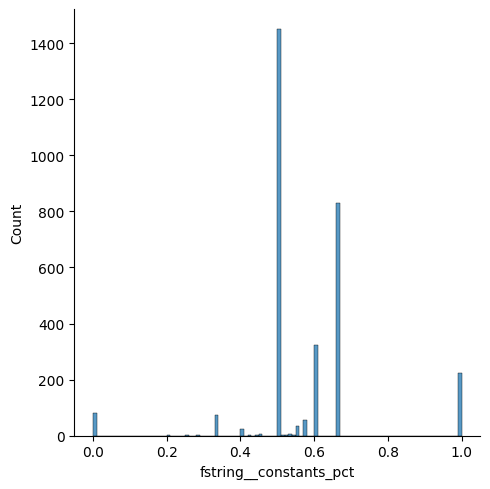

In [13]:
sns.displot(X['fstring__constants_pct'], bins=[i / 100 for i in range(0, 101)])

In [14]:
print_outliers_for_df_column(X, 'fstring__constants_pct')

El coeficiente MC (Medcouple Coefficient) de balanceo es: 0.3306583756627503
Dependiendo del coeficiente de MC se deben tomar unos límites u otros:
     |MC| < 0.3    ->  Tukey
     |MC| >=  0.3  ->  MAD
Rango valores atípicos leves (Tukey): [0.2499999701976776,0.916666716337204]
Rango valores atípicos MAD (Median Absolute Deviation): [-0.21093668788671494,1.2859462723135948]
-1.5IQR: 80 instancias tienen un valor para fstring__constants_pct inferior a 0.2499999701976776 (Q1-1.5*IQR) para fstring__constants_pct. Representando un 2.566% del total de instancias.
+1.5IQR: 225 instancias tienen un valor para fstring__constants_pct superior a 0.916666716337204 (Q3+1.5*IQR) para fstring__constants_pct. Representando un 7.216% del total de instancias.
MAD Inferior: 0 instancias tienen un valor para fstring__constants_pct inferior a -0.21093668788671494 para fstring__constants_pct. Representando un 0.0% del total de instancias.
MAD Superior: 0 instancias tienen un valor para fstring__constants

,fstring__number_of_elements,fstring__constants_pct,fstring__expressions_pct
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


In [15]:
analizar_bins(X, 'fstring__constants_pct')


--- Análisis de la feature: 'fstring__constants_pct' ---

Discretización en 3 bins de **igual anchura**:
  (-0.001, 0.333]: 156 (5.0%)
  (0.333, 0.667]: 2737 (87.8%)
  (0.667, 1.0]: 225 (7.2%)

Discretización en 3 bins de **igual frecuencia**:
  (-0.001, 0.5]: 1639 (52.6%)
  (0.5, 0.667]: 1254 (40.2%)
  (0.667, 1.0]: 225 (7.2%)


### Variable expressions_pct (3/3)
Esta variable representa la proporción de valores usados para parametrizar el JoinedStr que son expresiones. Toma los valores de 0.0 - 1.0. La media es 0.425.

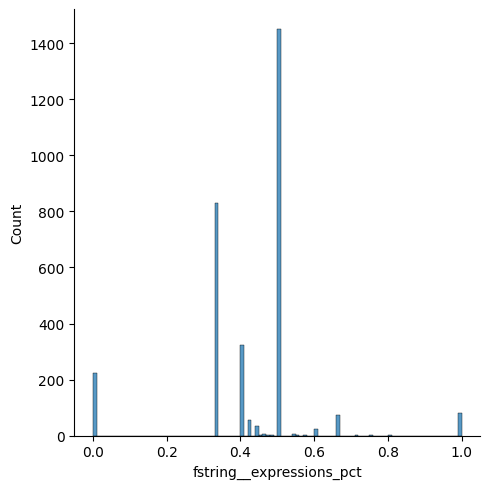

In [16]:
sns.displot(X['fstring__expressions_pct'], bins=[i / 100 for i in range(0, 101)])

In [17]:
print_outliers_for_df_column(X, 'fstring__expressions_pct')

El coeficiente MC (Medcouple Coefficient) de balanceo es: 0.03750479221343994
Dependiendo del coeficiente de MC se deben tomar unos límites u otros:
     |MC| < 0.3    ->  Tukey
     |MC| >=  0.3  ->  MAD
Rango valores atípicos leves (Tukey): [0.08333335816860199,0.7499999850988388]
Rango valores atípicos MAD (Median Absolute Deviation): [-0.1734318509697914,1.0984222665429115]
-1.5IQR: 225 instancias tienen un valor para fstring__expressions_pct inferior a 0.08333335816860199 (Q1-1.5*IQR) para fstring__expressions_pct. Representando un 7.216% del total de instancias.
+1.5IQR: 81 instancias tienen un valor para fstring__expressions_pct superior a 0.7499999850988388 (Q3+1.5*IQR) para fstring__expressions_pct. Representando un 2.598% del total de instancias.
MAD Inferior: 0 instancias tienen un valor para fstring__expressions_pct inferior a -0.1734318509697914 para fstring__expressions_pct. Representando un 0.0% del total de instancias.
MAD Superior: 0 instancias tienen un valor para fst

,fstring__number_of_elements,fstring__constants_pct,fstring__expressions_pct
count,306.000000,306.000000,306.000000
mean,1.029412,0.736765,0.263235
std,0.296069,0.439817,0.439817
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000
max,5.000000,1.000000,1.000000


In [18]:
analizar_bins(X, 'fstring__expressions_pct')


--- Análisis de la feature: 'fstring__expressions_pct' ---

Discretización en 3 bins de **igual anchura**:
  (-0.001, 0.333]: 1055 (33.8%)
  (0.333, 0.667]: 1981 (63.5%)
  (0.667, 1.0]: 82 (2.6%)

Discretización en 3 bins de **igual frecuencia**:
  (-0.001, 0.333]: 1055 (33.8%)
  (0.333, 0.5]: 1874 (60.1%)
  (0.5, 1.0]: 189 (6.1%)


## Multivariate

Isolation forest algorithm

In [19]:
from sklearn.ensemble import  IsolationForest

CONTAMINATION_FACTOR = 0.0012
isof_model = IsolationForest(contamination=CONTAMINATION_FACTOR, random_state=0)
isof_prediction = isof_model.fit_predict(X.values)
mask = isof_prediction == -1
full_table.loc[X.index[mask]]

,fstring__number_of_elements,fstring__constants_pct,fstring__expressions_pct,fstring__expertise_level
7760,43,0.511628,0.488372,BEGINNER


### IMPORTANTE
Analizar los outliers de la tabla

In [20]:
# Outliers
np.transpose(X[mask].describe(percentiles=[.25, .50, .75], include = ['object', 'float', 'bool', 'int']))

,count,mean,std,min,25%,50%,75%,max
fstring__number_of_elements,1.0,43.000000,NaN,43.000000,43.000000,43.000000,43.000000,43.000000
fstring__constants_pct,1.0,0.511628,NaN,0.511628,0.511628,0.511628,0.511628,0.511628
fstring__expressions_pct,1.0,0.488372,NaN,0.488372,0.488372,0.488372,0.488372,0.488372


In [21]:
# Non-Outliers
np.transpose(X[~mask].describe(percentiles=[.25, .50, .75], include = ['object', 'float', 'bool', 'int']))

,count,mean,std,min,25%,50%,75%,max
fstring__number_of_elements,3117.0,3.370548,2.084928,1.0,2.000000,3.0,4.000000,17.0
fstring__constants_pct,3117.0,0.575030,0.167729,0.0,0.500000,0.5,0.666667,1.0
fstring__expressions_pct,3117.0,0.424970,0.167729,0.0,0.333333,0.5,0.500000,1.0
